<a href="https://colab.research.google.com/github/Alaaeldinaly/Project2_Data_Cleaning_Transformation_Executed/blob/main/Project2_Data_Cleaning_Transformation_Executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Advanced Data Cleaning, Transformation, and Modeling Preparation

This notebook loads the Project 1 dataset, performs advanced data cleaning, creates new modeling features, prepares train/validation/test splits, and saves the cleaned data for future machine learning work. The dataset appears to contain NYC building energy benchmarking records, so the cleaning and feature engineering steps focus on energy use, emissions, building size, property type, and location fields.

In [ ]:
# =========================
# 1. Import libraries
# =========================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

try:
    from reportlab.lib import colors
    from reportlab.lib.pagesizes import letter, landscape
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak
except Exception as e:
    print("ReportLab import issue:", e)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ReportLab import issue: No module named 'reportlab'


In [ ]:
# Install ReportLab library for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 43.0 MB/s eta 0:00:00


## 2. Load dataset

The input file is the uploaded `cleaned_data.csv`. Output files are saved in the `project2_outputs` folder.

In [ ]:
# =========================
# 2. Load dataset
# =========================
INPUT_PATH = "/content/cleaned_full_dataset.csv"
OUTPUT_DIR = "/mnt/data/project2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

raw_df = pd.read_csv(INPUT_PATH)
print("Original shape:", raw_df.shape)
display(raw_df.head())

Original shape: (11746, 65)


,order,property_id,property_name,parent_property_id,parent_property_name,bbl_10_digits,nyc_borough_block_and_lot_bbl_self_reported,nyc_building_identification_number_bin,address_1_self_reported,postal_code,street_number,street_name,borough,dof_gross_floor_area,primary_property_type_self_selected,list_of_all_property_use_types_at_property,largest_property_use_type,largest_property_use_type_gross_floor_area_ft2,2nd_largest_property_use_type,2nd_largest_property_use_gross_floor_area_ft2,3rd_largest_property_use_type,3rd_largest_property_use_type_gross_floor_area_ft2,year_built,number_of_buildings_self_reported,occupancy,metered_areas_energy,metered_areas_water,energy_star_score,site_eui_kbtu_ft2,weather_normalized_site_eui_kbtu_ft2,weather_normalized_site_electricity_intensity_kwh_ft2,weather_normalized_site_natural_gas_intensity_therms_ft2,weather_normalized_source_eui_kbtu_ft2,fuel_oil_number2_use_kbtu,fuel_oil_number4_use_kbtu,natural_gas_use_kbtu,weather_normalized_site_natural_gas_use_therms,electricity_use_grid_purchase_kbtu,weather_normalized_site_electricity_kwh,total_ghg_emissions_metric_tons_co2e,direct_ghg_emissions_metric_tons_co2e,indirect_ghg_emissions_metric_tons_co2e,property_gfa_self_reported_ft2,water_use_all_water_sources_kgal,water_intensity_all_water_sources_gal_ft2,source_eui_kbtu_ft2,release_date,water_required,dof_benchmarking_submission_status,latitude,longitude,community_board,council_district,census_tract,nta,anomaly_flag,building_age,ghg_per_sqft,electricity_per_sqft,natural_gas_per_sqft,water_per_sqft_engineered,source_to_site_eui_ratio,lat_lon_interaction,high_energy_use,target_regression_ghg
0,4455,2946993,St. Mary's Home for Working Girls,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1.014270e+09,1-01427-0011,1043968.0,225 East 72nd Street,10021.0,225,EAST 72 STREET,Manhattan,95267.0,Residence Hall/Dormitory,Residence Hall/Dormitory,Residence Hall/Dormitory,67655.0,Retail Store,4662.0,Retail Store,16200.0,1960,1.0,100.0,Whole Building,Whole Building,1.0,151.85,157.869485,7.3,0.00,264.05,3312275.60,6906237.6,3.730000e+04,373.0,1690987.2,495599.9,1782.0375,2.0,919.9875,67655.0,2877.0,42.52,258.6,2017-02-22 12:34:11,Yes,In Compliance,40.769454,-73.959876,8.0,4.0,126.0,Lenox Hill-Roosevelt Island ...,1,57.0,0.026340,24.994268,0.551327,0.042525,1.738887,-3015.303762,1,1782.0375
1,653,4518118,The Bennett Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1.000890e+09,1-00089-0001,1001242.0,139 Fulton Street,10038.0,99,NASSAU STREET,Manhattan,100000.0,Office,Office,Office,100000.0,Retail Store,4662.0,Retail Store,16200.0,1883,1.0,100.0,Whole Building,Whole Building,87.0,73.50,72.100000,11.4,0.05,155.80,3312275.60,6906237.6,1.724000e+05,1919.0,4041710.2,1142242.3,620.9000,245.8,375.1000,100000.0,2519.0,25.19,160.4,2017-02-22 17:09:42,Yes,In Compliance,40.710531,-74.007441,1.0,1.0,1501.0,Battery Park City-Lower Manhattan ...,1,134.0,0.006209,40.417102,1.724000,0.025190,2.119728,-3012.882221,0,620.9000
2,13179,2916173,Namac Realty Corp,Not Applicable: Standalone Property,Not Applicable: Standalone Property,4.026780e+09,4-02678-0001,4059918.0,5801 Grand Ave,11378.0,58-13,GRAND AVENUE,Queens,51749.0,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,53000.0,Retail Store,4662.0,Retail Store,16200.0,1954,1.0,100.0,Whole Building,Whole Building,99.0,7.45,7.517525,0.2,0.10,8.90,2782042.15,6906237.6,3.075000e+05,3465.0,34551.5,10126.4,19.5000,16.3,3.2000,53000.0,26.2,0.49,8.1,2017-02-23 09:52:16,Yes,In Compliance,40.790059,-73.945037,4.0,6.0,958.0,Midtown-Midtown South ...,1,63.0,0.000368,0.651915,5.801887,0.000494,1.194631,-3016.222365,0,19.5000
3,7842,2660525,"Rockford Associates, LLC",Not Applicable: Standalone Property,Not Applicable: Standalone Property,2.032810e+09,2-03281-0040,2016459.0,357 E 201st Street,10458.0,357,EAST 201 STREET,Bronx,64824.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,50000.0,Retail Sto

## 3. Standardize column names and identify date fields

Column names are cleaned so they are easier to reference in code. The release date is parsed as a datetime field, which supports time-aware sorting and feature creation.

In [ ]:
# =========================
# 3. Standardize column names and parse dates
# =========================
def clean_column_name(col):
    return (
        str(col).strip().lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("#", "number")
        .replace("&", "and")
        .replace("²", "2")
        .replace("?", "")
    )

df = raw_df.copy()
df.columns = [clean_column_name(c) for c in df.columns]

# Remove repeated underscores and non-alphanumeric characters except underscores
import re
df.columns = [re.sub(r"[^a-z0-9_]", "", c) for c in df.columns]
df.columns = [re.sub(r"_+", "_", c).strip("_") for c in df.columns]

# Find and parse possible date columns
possible_date_cols = [c for c in df.columns if "date" in c or "time" in c]
for c in possible_date_cols:
    df[c] = pd.to_datetime(df[c], errors="coerce")

date_col = possible_date_cols[0] if possible_date_cols else None
if date_col:
    df = df.sort_values(date_col).reset_index(drop=True)

print("Detected date column:", date_col)
print("Cleaned column examples:", df.columns[:10].tolist())

Detected date column: release_date
Cleaned column examples: ['order', 'property_id', 'property_name', 'parent_property_id', 'parent_property_name', 'bbl_10_digits', 'nyc_borough_block_and_lot_bbl_self_reported', 'nyc_building_identification_number_bin', 'address_1_self_reported', 'postal_code']


## 4. Baseline data quality profile

This section records the original missing-value pattern, duplicate count, and before-cleaning snapshot. These outputs support the technical report and make the cleaning process auditable.

In [ ]:
# =========================
# 4. Baseline data quality profile
# =========================
before_snapshot = df.head(10).copy()
before_snapshot.to_csv(os.path.join(OUTPUT_DIR, "before_cleaning_snapshot.csv"), index=False)

quality_before = pd.DataFrame({
    "column": df.columns,
    "dtype_before": [str(df[c].dtype) for c in df.columns],
    "missing_before": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct_before": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "unique_before": [int(df[c].nunique(dropna=True)) for c in df.columns]
})
quality_before.to_csv(os.path.join(OUTPUT_DIR, "data_quality_before.csv"), index=False)

duplicate_count = int(df.duplicated().sum())
print("Duplicate rows before cleaning:", duplicate_count)
display(quality_before.sort_values("missing_pct_before", ascending=False).head(15))

Duplicate rows before cleaning: 0


,column,dtype_before,missing_before,missing_pct_before,unique_before
0,order,int64,0,0.0,11746
1,property_id,int64,0,0.0,11746
2,property_name,object,0,0.0,11740
3,parent_property_id,object,0,0.0,102
4,parent_property_name,object,0,0.0,103
5,bbl_10_digits,float64,0,0.0,11587
6,nyc_borough_block_and_lot_bbl_self_reported,object,0,0.0,11581
7,nyc_building_identification_number_bin,float64,0,0.0,11659
8,address_1_self_reported,object,0,0.0,11645
9,postal_code,float64,0,0.0,285


## 5. Error identification and correction

The code removes duplicates, converts numeric-looking text fields, fixes invalid negative values in fields that should not be negative, and removes columns with excessive missingness. Dropping extremely sparse columns helps reduce noise and prevents unstable imputations.

In [ ]:
# =========================
# 5. Error identification and correction
# =========================
# Remove duplicate rows
old_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows removed as duplicates:", old_rows - len(df))

# Convert object columns to numeric when most non-missing values look numeric
for col in df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(df[col].astype(str).str.replace(",", "", regex=False), errors="coerce")
    non_missing_original = df[col].notna().sum()
    if non_missing_original > 0 and converted.notna().sum() / non_missing_original >= 0.90:
        df[col] = converted

# Drop columns with more than 90% missing values
missing_pct = df.isna().mean()
cols_to_drop = missing_pct[missing_pct > 0.90].index.tolist()
df = df.drop(columns=cols_to_drop)
print("Columns dropped for >90% missingness:", cols_to_drop)

# Replace invalid negative values in nonnegative measurement fields with NaN before imputation
nonnegative_keywords = [
    "area", "score", "eui", "intensity", "use", "emissions", "gfa", "water", "gas",
    "electricity", "fuel", "steam", "volume", "occupancy", "buildings", "latitude", "longitude"
]
for col in df.select_dtypes(include=np.number).columns:
    if any(k in col for k in nonnegative_keywords) and "longitude" not in col:
        df.loc[df[col] < 0, col] = np.nan

print("Shape after structural cleaning:", df.shape)

Rows removed as duplicates: 0
Columns dropped for >90% missingness: []
Shape after structural cleaning: (11746, 65)


## 6. Advanced missing value handling

Numerical fields are imputed with a combination of interpolation, KNN imputation for moderately complete numeric fields, and median imputation as a fallback. Categorical fields are imputed with the mode or `Unknown` when no mode exists.

In [ ]:
# =========================
# 6. Missing value imputation
# =========================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Interpolation is useful for ordered records; it fills gaps smoothly when rows have a logical order.
if numeric_cols:
    df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")

# KNN imputation for numeric columns with enough non-missing data
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
knn_cols = [c for c in numeric_cols if df[c].notna().mean() >= 0.60 and df[c].isna().sum() > 0]
if knn_cols:
    imputer = KNNImputer(n_neighbors=5)
    df[knn_cols] = imputer.fit_transform(df[knn_cols])

# Median fallback for remaining numeric missing values
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Mode / Unknown imputation for categorical fields
for col in df.select_dtypes(include=["object", "category", "bool"]).columns:
    if df[col].isna().sum() > 0:
        mode_value = df[col].mode(dropna=True)
        fill_value = mode_value.iloc[0] if not mode_value.empty else "Unknown"
        df[col] = df[col].fillna(fill_value)

print("Remaining missing values:", int(df.isna().sum().sum()))

Remaining missing values: 0


## 7. Outlier detection and treatment

Outliers are capped using the IQR method for important numeric energy and emissions variables. Isolation Forest is also used to create an anomaly flag rather than automatically deleting rows, preserving potentially meaningful unusual buildings.

In [ ]:
# =========================
# 7. Outlier detection and treatment
# =========================
critical_patterns = ["eui", "emissions", "electricity", "natural_gas", "water", "gfa", "floor_area"]
critical_numeric_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if any(p in c for p in critical_patterns)
]

outlier_report = []
for col in critical_numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before_outliers = int(((df[col] < lower) | (df[col] > upper)).sum())
    df[col] = df[col].clip(lower, upper)
    outlier_report.append({"column": col, "lower_cap": lower, "upper_cap": upper, "values_capped": before_outliers})

outlier_report_df = pd.DataFrame(outlier_report)
outlier_report_df.to_csv(os.path.join(OUTPUT_DIR, "outlier_capping_report.csv"), index=False)

# Isolation Forest anomaly flag
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
model_cols = [c for c in numeric_cols if df[c].nunique() > 1]
if len(model_cols) >= 2:
    iso = IsolationForest(contamination=0.02, random_state=42)
    df["anomaly_flag"] = iso.fit_predict(df[model_cols])
else:
    df["anomaly_flag"] = 1

print("Number of broad anomaly rows flagged:", int((df["anomaly_flag"] == -1).sum()))
display(outlier_report_df.head(10))

Number of broad anomaly rows flagged: 235


,column,lower_cap,upper_cap,values_capped
0,dof_gross_floor_area,-7.784625e+04,3.038338e+05,0
1,largest_property_use_type_gross_floor_area_ft2,-6.687788e+04,2.853411e+05,0
2,2nd_largest_property_use_gross_floor_area_ft2,-1.913890e+04,4.461928e+04,0
3,3rd_largest_property_use_type_gross_floor_area...,-1.136754e+04,2.583857e+04,0
4,site_eui_kbtu_ft2,7.450000e+00,1.518500e+02,0
5,weather_normalized_site_eui_kbtu_ft2,7.517525e+00,1.578695e+02,178
6,weather_normalized_site_electricity_intensity_...,-4.150000e+00,1.705000e+01,0
7,weather_normalized_site_natural_gas_intensity_...,-8.000000e-01,1.600000e+00,165
8,weather_normalized_source_eui_kbtu_ft2,2.850000e+00,2.640500e+02,0
9,natural_gas_use_kbtu,-7.288682e+06,1.558793e+07,0


## 8. Feature engineering

New variables are created to improve predictive modeling. These include building age, energy-use ratios, emissions intensity, water intensity alternatives, and location/property-type encoded fields.

In [ ]:
# =========================
# 8. Feature engineering
# =========================
# Helper function to find columns that may vary by exact naming
cols = df.columns.tolist()
def find_col(*keywords):
    for c in cols:
        if all(k in c for k in keywords):
            return c
    return None

year_col = find_col("year", "built")
gfa_col = find_col("property", "gfa") or find_col("gross", "floor", "area")
site_eui_col = find_col("site", "eui")
source_eui_col = find_col("source", "eui")
ghg_col = find_col("total", "ghg", "emissions")
elec_col = find_col("electricity", "grid", "purchase") or find_col("electricity", "use")
gas_col = find_col("natural", "gas", "use")
water_col = find_col("water", "use")
lat_col = find_col("latitude")
lon_col = find_col("longitude")

current_year = 2017  # release year in this dataset
if year_col:
    df["building_age"] = current_year - df[year_col]
    df.loc[df["building_age"] < 0, "building_age"] = np.nan
    df["building_age"] = df["building_age"].fillna(df["building_age"].median())

if ghg_col and gfa_col:
    df["ghg_per_sqft"] = df[ghg_col] / df[gfa_col].replace(0, np.nan)

if elec_col and gfa_col:
    df["electricity_per_sqft"] = df[elec_col] / df[gfa_col].replace(0, np.nan)

if gas_col and gfa_col:
    df["natural_gas_per_sqft"] = df[gas_col] / df[gfa_col].replace(0, np.nan)

if water_col and gfa_col:
    df["water_per_sqft_engineered"] = df[water_col] / df[gfa_col].replace(0, np.nan)

if site_eui_col and source_eui_col:
    df["source_to_site_eui_ratio"] = df[source_eui_col] / df[site_eui_col].replace(0, np.nan)

if lat_col and lon_col:
    df["lat_lon_interaction"] = df[lat_col] * df[lon_col]

# Create modeling target examples
if site_eui_col:
    df["high_energy_use"] = (df[site_eui_col] >= df[site_eui_col].quantile(0.75)).astype(int)
if ghg_col:
    df["target_regression_ghg"] = df[ghg_col]

# Fill engineered ratio NaNs created by zero division
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isna().sum() > 0:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

print("New engineered columns:", [c for c in df.columns if c not in raw_df.columns][:20])

New engineered columns: []


## 9. Save cleaned data and after-cleaning quality report

The cleaned dataset and comparison files are saved for reporting and future use.

In [ ]:
# =========================
# 9. Save cleaned dataset and quality outputs
# =========================
after_snapshot = df.head(10).copy()
after_snapshot.to_csv(os.path.join(OUTPUT_DIR, "after_cleaning_snapshot.csv"), index=False)

quality_after = pd.DataFrame({
    "column": df.columns,
    "dtype_after": [str(df[c].dtype) for c in df.columns],
    "missing_after": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct_after": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
    "unique_after": [int(df[c].nunique(dropna=True)) for c in df.columns]
})
quality_after.to_csv(os.path.join(OUTPUT_DIR, "data_quality_after.csv"), index=False)

df.to_csv(os.path.join(OUTPUT_DIR, "cleaned_full_dataset.csv"), index=False)
print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (11746, 65)


,order,property_id,property_name,parent_property_id,parent_property_name,bbl_10_digits,nyc_borough_block_and_lot_bbl_self_reported,nyc_building_identification_number_bin,address_1_self_reported,postal_code,street_number,street_name,borough,dof_gross_floor_area,primary_property_type_self_selected,list_of_all_property_use_types_at_property,largest_property_use_type,largest_property_use_type_gross_floor_area_ft2,2nd_largest_property_use_type,2nd_largest_property_use_gross_floor_area_ft2,3rd_largest_property_use_type,3rd_largest_property_use_type_gross_floor_area_ft2,year_built,number_of_buildings_self_reported,occupancy,metered_areas_energy,metered_areas_water,energy_star_score,site_eui_kbtu_ft2,weather_normalized_site_eui_kbtu_ft2,weather_normalized_site_electricity_intensity_kwh_ft2,weather_normalized_site_natural_gas_intensity_therms_ft2,weather_normalized_source_eui_kbtu_ft2,fuel_oil_number2_use_kbtu,fuel_oil_number4_use_kbtu,natural_gas_use_kbtu,weather_normalized_site_natural_gas_use_therms,electricity_use_grid_purchase_kbtu,weather_normalized_site_electricity_kwh,total_ghg_emissions_metric_tons_co2e,direct_ghg_emissions_metric_tons_co2e,indirect_ghg_emissions_metric_tons_co2e,property_gfa_self_reported_ft2,water_use_all_water_sources_kgal,water_intensity_all_water_sources_gal_ft2,source_eui_kbtu_ft2,release_date,water_required,dof_benchmarking_submission_status,latitude,longitude,community_board,council_district,census_tract,nta,anomaly_flag,building_age,ghg_per_sqft,electricity_per_sqft,natural_gas_per_sqft,water_per_sqft_engineered,source_to_site_eui_ratio,lat_lon_interaction,high_energy_use,target_regression_ghg
0,4455,2946993,St. Mary's Home for Working Girls,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1.014270e+09,1-01427-0011,1043968.0,225 East 72nd Street,10021.0,225,EAST 72 STREET,Manhattan,95267.0,Residence Hall/Dormitory,Residence Hall/Dormitory,Residence Hall/Dormitory,67655.0,Retail Store,4662.0,Retail Store,16200.0,1960,1.0,100.0,Whole Building,Whole Building,1.0,151.85,157.869485,7.3,0.00,264.05,3312275.60,6906237.6,3.730000e+04,373.0,1690987.2,495599.9,1782.0375,2.0,919.9875,67655.0,2877.0,42.52,258.6,2017-02-22 12:34:11,Yes,In Compliance,40.769454,-73.959876,8.0,4.0,126.0,Lenox Hill-Roosevelt Island ...,1,57.0,0.026340,24.994268,0.551327,0.042525,1.738887,-3015.303762,1,1782.0375
1,653,4518118,The Bennett Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,1.000890e+09,1-00089-0001,1001242.0,139 Fulton Street,10038.0,99,NASSAU STREET,Manhattan,100000.0,Office,Office,Office,100000.0,Retail Store,4662.0,Retail Store,16200.0,1883,1.0,100.0,Whole Building,Whole Building,87.0,73.50,72.100000,11.4,0.05,155.80,3312275.60,6906237.6,1.724000e+05,1919.0,4041710.2,1142242.3,620.9000,245.8,375.1000,100000.0,2519.0,25.19,160.4,2017-02-22 17:09:42,Yes,In Compliance,40.710531,-74.007441,1.0,1.0,1501.0,Battery Park City-Lower Manhattan ...,1,134.0,0.006209,40.417102,1.724000,0.025190,2.119728,-3012.882221,0,620.9000
2,13179,2916173,Namac Realty Corp,Not Applicable: Standalone Property,Not Applicable: Standalone Property,4.026780e+09,4-02678-0001,4059918.0,5801 Grand Ave,11378.0,58-13,GRAND AVENUE,Queens,51749.0,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,Non-Refrigerated Warehouse,53000.0,Retail Store,4662.0,Retail Store,16200.0,1954,1.0,100.0,Whole Building,Whole Building,99.0,7.45,7.517525,0.2,0.10,8.90,2782042.15,6906237.6,3.075000e+05,3465.0,34551.5,10126.4,19.5000,16.3,3.2000,53000.0,26.2,0.49,8.1,2017-02-23 09:52:16,Yes,In Compliance,40.790059,-73.945037,4.0,6.0,958.0,Midtown-Midtown South ...,1,63.0,0.000368,0.651915,5.801887,0.000494,1.194631,-3016.222365,0,19.5000
3,7842,2660525,"Rockford Associates, LLC",Not Applicable: Standalone Property,Not Applicable: Standalone Property,2.032810e+09,2-03281-0040,2016459.0,357 E 201st Street,10458.0,357,EAST 201 STREET,Bronx,64824.0,Multifamily Housing,Multifamily Housing,Multifamily Housing,50000.0,Retail Sto

## 10. Visualization outputs for the report

The figures below compare missingness, show selected distributions, and summarize correlations among important numeric variables.

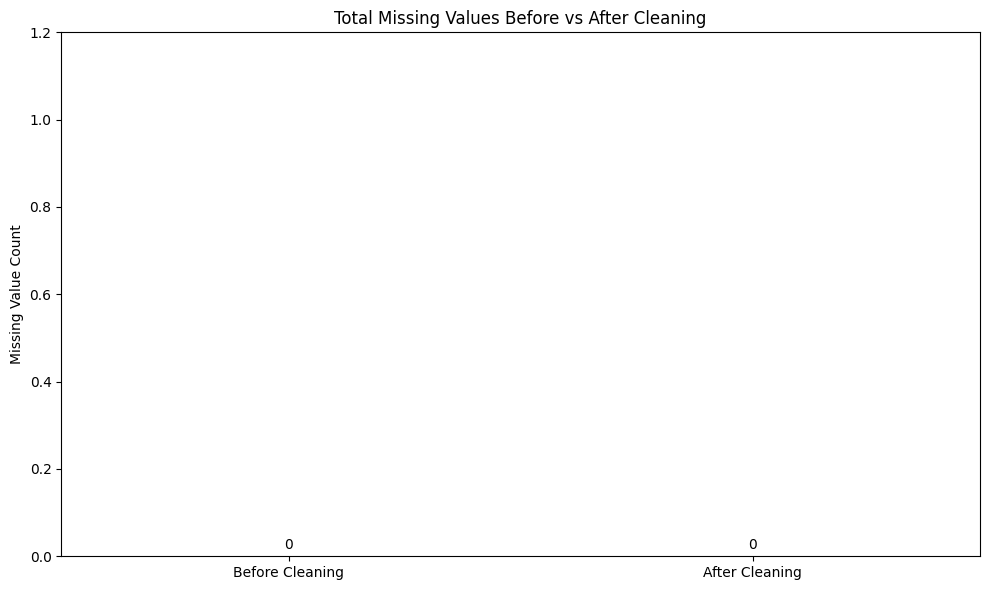

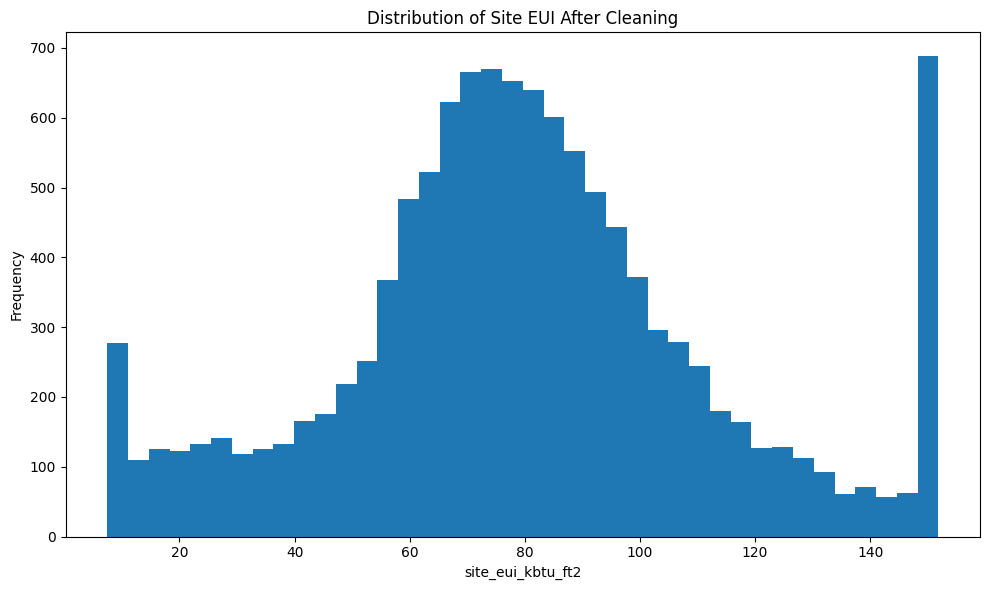

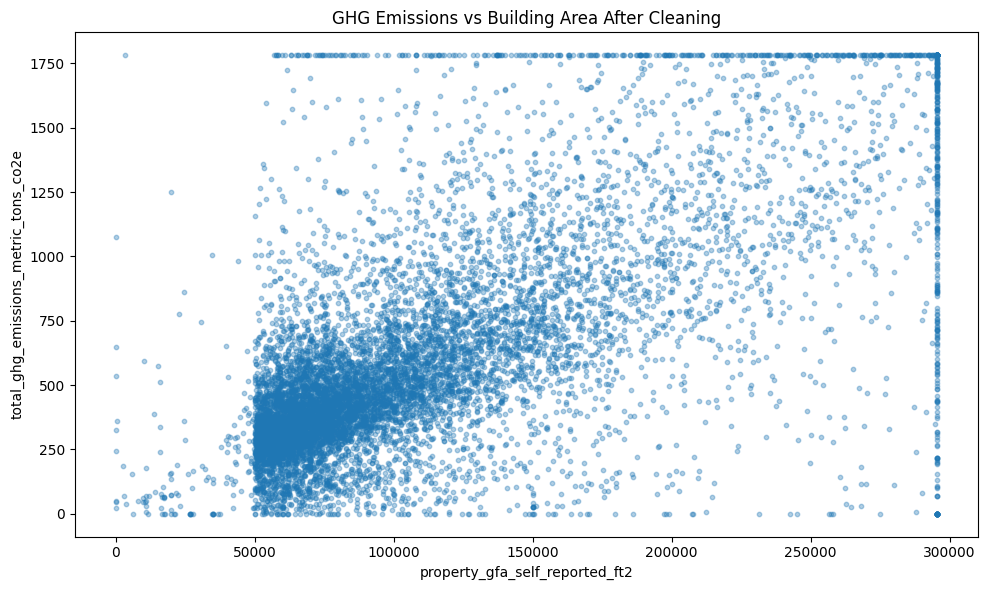

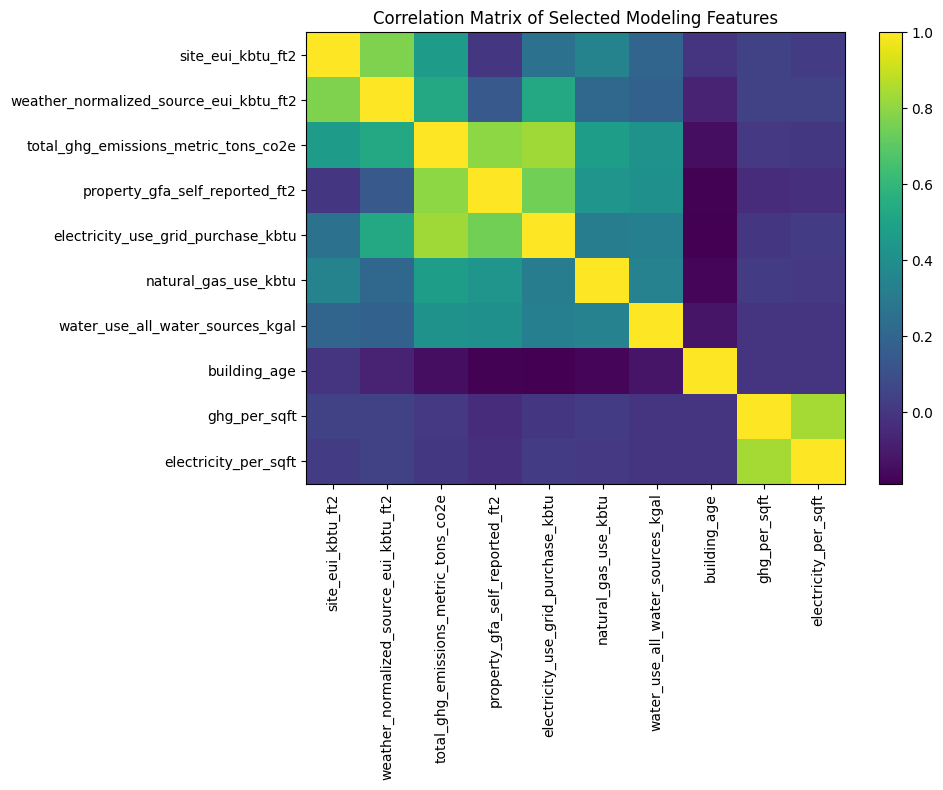

In [26]:
# =========================
# 10. Create visualizations
# =========================
# Missing values before vs after
fig, ax = plt.subplots(figsize=(10, 6))
before_missing_total = raw_df.isna().sum().sum()
after_missing_total = df.isna().sum().sum()

bars = ax.bar(
    ["Before Cleaning", "After Cleaning"],
    [before_missing_total, after_missing_total]
)
ax.set_title("Total Missing Values Before vs After Cleaning")
ax.set_ylabel("Missing Value Count")
ax.bar_label(bars, padding=3)
ax.set_ylim(0, max(before_missing_total, after_missing_total, 1) * 1.2)

plt.tight_layout()
missing_fig = os.path.join(OUTPUT_DIR, "missing_values_before_after.png")
plt.savefig(missing_fig, dpi=150, bbox_inches="tight")
plt.show()

# Distribution for Site EUI if available
if site_eui_col and site_eui_col in df.columns:
    site_vals = pd.to_numeric(df[site_eui_col], errors="coerce").dropna()
    if len(site_vals) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(site_vals, bins=40)
        ax.set_title("Distribution of Site EUI After Cleaning")
        ax.set_xlabel(site_eui_col)
        ax.set_ylabel("Frequency")
        plt.tight_layout()
        site_eui_fig = os.path.join(OUTPUT_DIR, "site_eui_distribution.png")
        plt.savefig(site_eui_fig, dpi=150, bbox_inches="tight")
        plt.show()

# GHG vs GFA scatter if both exist
if ghg_col and gfa_col and ghg_col in df.columns and gfa_col in df.columns:
    scatter_df = df[[gfa_col, ghg_col]].copy()
    scatter_df[gfa_col] = pd.to_numeric(scatter_df[gfa_col], errors="coerce")
    scatter_df[ghg_col] = pd.to_numeric(scatter_df[ghg_col], errors="coerce")
    scatter_df = scatter_df.dropna()

    if len(scatter_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(scatter_df[gfa_col], scatter_df[ghg_col], alpha=0.35, s=10)
        ax.set_title("GHG Emissions vs Building Area After Cleaning")
        ax.set_xlabel(gfa_col)
        ax.set_ylabel(ghg_col)
        plt.tight_layout()
        scatter_fig = os.path.join(OUTPUT_DIR, "ghg_vs_gfa.png")
        plt.savefig(scatter_fig, dpi=150, bbox_inches="tight")
        plt.show()

# Correlation heatmap using matplotlib only
selected_corr_cols = [
    c for c in [
        site_eui_col, source_eui_col, ghg_col, gfa_col,
        elec_col, gas_col, water_col,
        "building_age", "ghg_per_sqft", "electricity_per_sqft"
    ]
    if c and c in df.columns
]

selected_corr_cols = list(dict.fromkeys(selected_corr_cols))[:10]

if len(selected_corr_cols) >= 2:
    corr_df = df[selected_corr_cols].copy()
    for col in corr_df.columns:
        corr_df[col] = pd.to_numeric(corr_df[col], errors="coerce")

    corr_df = corr_df.dropna(axis=1, how="all")

    if corr_df.shape[1] >= 2:
        corr = corr_df.corr()

        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(corr.values, aspect="auto")
        ax.set_xticks(range(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=90)
        ax.set_yticks(range(len(corr.columns)))
        ax.set_yticklabels(corr.columns)
        ax.set_title("Correlation Matrix of Selected Modeling Features")
        fig.colorbar(im, ax=ax)

        plt.tight_layout()
        corr_fig = os.path.join(OUTPUT_DIR, "correlation_matrix.png")
        plt.savefig(corr_fig, dpi=150, bbox_inches="tight")
        plt.show()

## 11. Encoding, scaling, and data splitting

The dataset is split into training, validation, and test sets. Numerical columns are standardized, while categorical columns are one-hot encoded. This creates model-ready feature matrices while preventing the validation and test sets from influencing preprocessing fitted on the training set.

In [ ]:
# =========================
# 11. Prepare model-ready data splits
# =========================
classification_target = "high_energy_use" if "high_energy_use" in df.columns else None
regression_target = "target_regression_ghg" if "target_regression_ghg" in df.columns else None

# Use classification target for the prepared split; regression target is also saved for future use.
target_col = classification_target or regression_target
print("Selected target:", target_col)

exclude_cols = [c for c in [classification_target, regression_target] if c]
X = df.drop(columns=exclude_cols, errors="ignore")
y = df[target_col]

# Drop raw date columns and high-cardinality identifiers/text fields to keep modeling matrix efficient.
datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
X = X.drop(columns=datetime_cols, errors="ignore")

id_text_keywords = ["id", "name", "address", "street", "bbl", "bin"]
high_cardinality_cats = [
    c for c in X.select_dtypes(include=["object", "category", "bool"]).columns
    if X[c].nunique(dropna=True) > 50 or any(k in c for k in id_text_keywords)
]
X = X.drop(columns=high_cardinality_cats, errors="ignore")
print("Dropped high-cardinality/id-like categorical columns:", high_cardinality_cats)

stratify_arg = y if target_col == classification_target and y.nunique() == 2 else None
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=stratify_arg
)

stratify_temp = y_temp if stratify_arg is not None else None
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=stratify_temp
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# OneHotEncoder parameter changed across sklearn versions, so this keeps the notebook compatible.
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Raw train shape:", X_train.shape)
print("Processed train shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Test shape:", X_test_processed.shape)

Selected target: high_energy_use
Dropped high-cardinality/id-like categorical columns: ['property_name', 'parent_property_id', 'parent_property_name', 'nyc_borough_block_and_lot_bbl_self_reported', 'address_1_self_reported', 'street_number', 'street_name', 'primary_property_type_self_selected', 'list_of_all_property_use_types_at_property', 'largest_property_use_type', '2nd_largest_property_use_type', 'nta']
Raw train shape: (8222, 50)
Processed train shape: (8222, 108)
Validation shape: (1762, 108)
Test shape: (1762, 108)


## 12. Save training, validation, and test files

The raw split files are saved as CSVs, and the transformed matrices are saved as NumPy arrays for direct model training.

In [ ]:
# =========================
# 12. Save model inputs and preprocessing object
# =========================
import pickle

X_train.to_csv(os.path.join(OUTPUT_DIR, "X_train.csv"), index=False)
X_val.to_csv(os.path.join(OUTPUT_DIR, "X_validation.csv"), index=False)
X_test.to_csv(os.path.join(OUTPUT_DIR, "X_test.csv"), index=False)

y_train.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_val.to_csv(os.path.join(OUTPUT_DIR, "y_validation.csv"), index=False)
y_test.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

np.save(os.path.join(OUTPUT_DIR, "X_train_processed.npy"), X_train_processed)
np.save(os.path.join(OUTPUT_DIR, "X_validation_processed.npy"), X_val_processed)
np.save(os.path.join(OUTPUT_DIR, "X_test_processed.npy"), X_test_processed)

with open(os.path.join(OUTPUT_DIR, "preprocessor.pkl"), "wb") as f:
    pickle.dump(preprocessor, f)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "raw_features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    "processed_features": [X_train_processed.shape[1], X_val_processed.shape[1], X_test_processed.shape[1]]
})
split_summary.to_csv(os.path.join(OUTPUT_DIR, "split_summary.csv"), index=False)
display(split_summary)

,split,rows,raw_features,processed_features
0,train,8222,50,108
1,validation,1762,50,108
2,test,1762,50,108


## 13. Create the technical report PDF

This final section generates a PDF report that documents the cleaning, transformation, and modeling-preparation decisions. It includes before-and-after snapshots and saved visualizations.

In [ ]:
# =========================
# 13. Generate technical report PDF
# =========================
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter, landscape
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, PageBreak

report_path = "/mnt/data/Project2_Technical_Report.pdf"
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="Small", parent=styles["BodyText"], fontSize=8, leading=10))
styles.add(ParagraphStyle(name="Body", parent=styles["BodyText"], fontSize=10, leading=13))
styles.add(ParagraphStyle(name="Heading", parent=styles["Heading2"], spaceBefore=10, spaceAfter=6))

def para(text, style="Body"):
    return Paragraph(str(text), styles[style])

def make_table_from_df(input_df, max_rows=6, max_cols=7):
    temp = input_df.copy().head(max_rows).iloc[:, :max_cols]
    temp = temp.astype(str)
    data = [temp.columns.tolist()] + temp.values.tolist()
    tbl = Table(data, repeatRows=1)
    tbl.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTSIZE", (0, 0), (-1, -1), 6),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ]))
    return tbl

story = []
doc = SimpleDocTemplate(report_path, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)

story.append(para("Project 2 Technical Report: Data Cleaning, Transformation, and Modeling Preparation", "Title"))
story.append(Spacer(1, 0.15 * inch))
story.append(para(f"Input dataset contained {raw_df.shape[0]:,} rows and {raw_df.shape[1]:,} columns. The final cleaned dataset contains {df.shape[0]:,} rows and {df.shape[1]:,} columns."))
story.append(para(f"Total missing values decreased from {int(raw_df.isna().sum().sum()):,} to {int(df.isna().sum().sum()):,}."))

story.append(para("Methods Used", "Heading"))
story.append(para("The workflow standardized column names, parsed date fields, removed duplicate rows, corrected invalid negative values in nonnegative measurement fields, removed extremely sparse columns, and imputed missing values. Numeric fields were handled using interpolation, KNN imputation where appropriate, and median fallback imputation. Categorical variables were filled with their mode or Unknown when needed."))

story.append(para("Outlier Management", "Heading"))
story.append(para("Critical energy, emissions, area, electricity, gas, and water variables were capped with the IQR method. This strategy reduces the influence of extreme values while preserving rows that may represent large or unusual buildings. An Isolation Forest anomaly flag was also added so unusual records can be investigated during later modeling."))

story.append(para("Feature Engineering and Modeling Preparation", "Heading"))
story.append(para("New features included building age, emissions per square foot, electricity per square foot, natural gas per square foot, water per square foot, source-to-site EUI ratio, and location interaction. A classification target was created to identify high-energy-use buildings based on the top quartile of Site EUI. A regression target was also saved using total GHG emissions."))
story.append(para("The data was split into training, validation, and test sets using a 70/15/15 split. Numerical features were standardized and categorical variables were one-hot encoded. The preprocessing object was fitted only on the training data to prevent data leakage."))

story.append(para("Before-Cleaning Snapshot", "Heading"))
story.append(make_table_from_df(before_snapshot, max_rows=5, max_cols=6))
story.append(Spacer(1, 0.15 * inch))
story.append(para("After-Cleaning Snapshot", "Heading"))
story.append(make_table_from_df(after_snapshot, max_rows=5, max_cols=6))

story.append(PageBreak())
story.append(para("Visual Evidence", "Heading"))
for img_path, caption in [
    (os.path.join(OUTPUT_DIR, "missing_values_before_after.png"), "Missing values before and after cleaning"),
    (os.path.join(OUTPUT_DIR, "site_eui_distribution.png"), "Distribution of Site EUI after cleaning"),
    (os.path.join(OUTPUT_DIR, "ghg_vs_gfa.png"), "GHG emissions compared with building area"),
    (os.path.join(OUTPUT_DIR, "correlation_matrix.png"), "Correlation matrix for selected modeling features"),
]:
    if os.path.exists(img_path):
        story.append(para(caption, "Heading"))
        story.append(Image(img_path, width=6.3*inch, height=3.8*inch))
        story.append(Spacer(1, 0.15*inch))

story.append(para("Saved Deliverables", "Heading"))
story.append(para("The cleaned full dataset, train/validation/test splits, processed NumPy arrays, quality reports, visualizations, and preprocessing pipeline were saved in the project2_outputs directory. These files prepare the dataset for advanced analysis and predictive modeling."))

doc.build(story)
print("PDF report saved to:", report_path)

PDF report saved to: /mnt/data/Project2_Technical_Report.pdf
